# Day 19 In-Class Assignment

---


### <p style="text-align: right;"> &#9989; Put your name here.</p>

#### <p style="text-align: right;"> &#9989; Put your group member names here.</p>

## Can bugs be controlled with conservation agriculture systems?

<img src="https://raw.githubusercontent.com/ejamezquita/plnt_sci2500/refs/heads/main/images/western_corn_rootworm.jpg" style="display:block; margin-left: auto; margin-right: auto; width: 30%" alt="Zoomed-in picture of rootworms eating a corn plant in the field.">
<p style="font-size:0.85em; text-align: center;">Credits: <a href="https://extension.usu.edu/planthealth/ipm/notes_ag/veg-western-corn-rootworm" target="_blank">USU Extension</a></p>

### Learning goals of today's assignment

* Practice computing and interpreting t-tests with SciPy.
* Determine whether WCR larval weights are statistically different under different growth and treatment conditions.
* Partly reproduce the bar plots of Figure 1 of the reference paper.

### Assignment instructions

Work with your group to complete this assignment. Instructions for submitting this assignment are at the end of the notebook. The assignment is due at the end of class.


---

## Background

Sustainable agricultural management practices aimed at improving soil health can alter the soil microbiome, which can influence plant health and defenses against insects. The western corn rootworm (WCR), *Diabrotica virgifera virgifera* LeConte, is a major belowground pest of corn. Pest management relies heavily on the planting of transgenic crops expressing *Bacillus thuringiensis* (Bt) toxins.

In this dataset, authors ask how corn-WCR interactions via the soil microbiome are affected by field management style when combined with transgenic Bt corn.
- **Conservational management**: Extended corn-soybean-wheat rotation with cover crops under no-till.
- **Conventional (traditional) management**: Corn-soybean rotation under mulch tillage and no cover crops.

More details in:

> Paddock, K.J., Veum, K.S., Finke, D.L. et al. (2024) [Soil microbes from conservation agriculture systems reduce growth of Bt-resistant western corn rootworm larvae](https://doi.org/10.1007/s10340-023-01725-2). *J Pest Sci* **97**, 1677&ndash;1689

<img src="https://raw.githubusercontent.com/ejamezquita/plnt_sci2500/refs/heads/main/images/paddock_etal_2024_f1.png" style="display:block; margin-left: auto; margin-right: auto; width: 50%" alt="Linear relationship between protein and oil content for various African soybean cultivars.">
<p style="font-size:0.85em; text-align: center;">Credits: <a href="https://doi.org/10.1007/s10340-023-01725-2" target="_blank">Paddock et al (2024)</a></p>


&#9989;&nbsp; **Question 1**

- What is reflected on the x-axis?
- What is reflected on the y-axis?
- In your own words, what information do you get out of this figure?

<font size=6 color="#009600">&#9998;</font> *Put your answer here*

---

## 1. Setting everything up

Before jumping straight into linear regressions, we need to go through the usual setup steps.

We import the usual suspects: NumPy, pandas, matplotlib, and Scipy's stats

In [1]:
# Remember that it is always good coding practice to import your libraries at the top before doing anything else.

from scipy import stats
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

&#9989;&nbsp; **Task 2**

- With pandas, load the dataset `210602_fitness_data.csv`.
- You should have 144 rows and 21 columns of data.

In [2]:
# Load the data


&#9989;&nbsp; **Question 3**

- What columns will you need to reproduce [Fig. 1A from Paddock et al. (2024)](https://doi.org/10.1007/s10340-023-01725-2) (the figure displayed in Background)?

<font size=6 color="#009600">&#9998;</font> *Put your answer here.*


&#9989;&nbsp; **Task 4**

- Now edit your code in Task 2 to remove all the pesky NaNs *just* from those columns. Else you risk discarding more columns than you should.
- You should keep 81 rows and the 21 columns

*Hint*: Use the `subset` argument [from `.dropna()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dropna.html). 

&#9989;&nbsp; **Task 5: Exploring the data**

- Use `.unique()` to get the unique different values found across columns `treatment`, `corn_trait`, and `colony`. (You'll need to repeat `unique` three times).
- How are those unique values reflected in Figure 1A?

In [3]:
# Your plot

&#9989;&nbsp; **Task 6: data wrangling**

Let's focus on the very first column in 1A (striped olive)

- Define variables `colony`, `ctrait`, and `treatment` corresponding to Bt-susceptible WCRs, Bt-expressing corn, and conservational agricultural treatment values (the ones you just printed above).
- With *masking* and `.loc`, define a Series containing only the average larval weight when looking at data from Bt-susceptible WCRs, Bt-expressing corn, and conservational agricultural treatments.
- Print the mean values of that subset. Do you remember the pandas function to get means?
- Does the value seem to match the bar from Figure 1A?

In [4]:
# Your code

&#9989;&nbsp; **Task 7**

- Repeat Task 6, except that now you'll consider *non* Bt-expressing corn.
- Store your Series in a different variable.
- Compare your mean value to the corresponding bar from Figure 1A (second column, plain olive).

In [5]:
# Your code

&#9989;&nbsp; **Task 8**

- Repeat Tasks 6-7 *minus* the manual number comparisons, except that now you'll consider conventional (traditional) management.
    - You should produce *two* more Series
- Define `weights` as a list of these Series (four Series in total).

In [6]:
# Your code
weights = []

---

## 2. Visualizing before any statistical analyses: jitterplots

Before doing any t-test, lets visualize the raw data points as scatterplots. To avoid plotting the data in a single line, we will add it a bit of a jitter. This is done by moving horizontally each data point a nudge, where nudge means a random value between -0.15 and 0.15. The choice of 0.15 is purely aesthetic.

We can use NumPy to get randomly* distributed numbers.

*<sub>Computers don't generate truly random number but they rather simulate them based on a `seed` value. In theory, if you know the original `seed`, you can predict the number the computer will generate (which is the opposite meaning of random). Unless you are doing cryptography, this is not a big deal at all. That being said, fixing a `seed` value is important for others to reproduce your exact results.</sub>

In [7]:
# Generating "random" numbers to nudge our data points
# The seed can be any number, but 42 is usually chosen in homage to The Hitchhiker's Guide to the Galaxy
rng = np.random.default_rng(seed = 42)

# nudge is an array with 1000 random numbers between -0.15 and 0.15
nudge = rng.uniform(-0.15, 0.15, 1000)
print(nudge[:10])

[ 0.08218681 -0.01833647  0.10757938  0.05921041 -0.1217468   0.14268671
  0.07834191  0.08581929 -0.11156591 -0.01488422]


&#9989;&nbsp; **Task 9**

The code below makes a *jitterplot* (a scatterplot where the individual points have some random jitter). The white diamond represents the sample mean along with the 95% confidence intervals. Notice that it is the same data as in Figure 1A.

- Comment every line of the code

IndexError: list index out of range

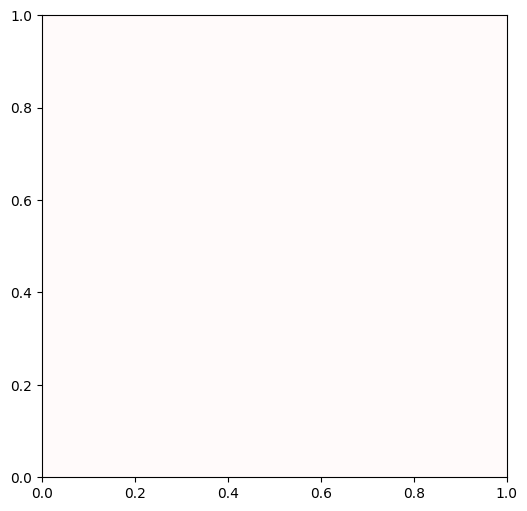

In [8]:
# Comment every line except for those related to CIs

colors = ['b', 'b', 'b', 'b']
xpos = [0,1,3,4]

fig, ax = plt.subplots( figsize=(6,6) )
ax.set_facecolor('snow')
for i in range(len(xpos)):

    yvalues = weights[i]
    ax.scatter(xpos[i]+nudge[:len(yvalues)], yvalues, fc=colors[i], zorder=2)

    ci = stats.t.ppf(0.975, len(yvalues)-1)*yvalues.sem()
    ax.errorbar(xpos[i], yvalues.mean(), yerr=ci, color='k', mew=1, elinewidth=1, capsize=5, mfc='w', marker='D', zorder=3)

ax.set_xticks(xpos, ['BT','ISO','BT','ISO']);

&#9989;&nbsp; **Task 10**

In a similar spirit as Figure 1A, edit the code above (or make a copy of it in a cell below) so that:
- Bt- and non Bt-expressing corn samples correspond to different markers
- The conservational and traditional management markers have different colors
- Add a title and y-axis label

Getting a similar legend is a bit trickier, so we'll leave that for another day.

&#9989;&nbsp; **Question 11**

As a rule of thumb:
- If the 95% Confidence Intervals of two samples **do not** overlap, then it is very likely that their means are statistically different.
- If they overlap a lot, then it is very likely that there is no difference between their means.
- If they sort of overlap, the two-sample test can go either way.

Based solely on the visualization, answer four questions:

- Could there be a significant difference in larval weight between Bt- and non Bt-expressing corn under conservational management?
- What about under traditional management?
- What about between traditional and conservational management systems when looking just at Bt-expressing corn?
- And when looking just at non Bt-expressing corn?

<font size=6 color="#009600">&#9998;</font> *Put your answer here.*


---

## 3. Computing Welch's t-tests with `stats.ttest_ind`

Now it's time to check if the statistics support our visual intution.

&#9989;&nbsp; **Task 12**

- Do three Welch's t-tests to check the same questions as in Q9.
- If we go with the standard &nbsp;$\alpha = 0.05$&nbsp; significance threshold, do the t-tests support your intuition from Question 9?
- Do your conclusions match with those presented by Paddock et al (2024) in Figure 1A?

In [9]:
# Your code

---

## 4. [Time-permitting] Extending our analyses to Bt-resistant critters

So far we have focused on 1A when examining the larval weight of Bt-*susceptible* WCRs. Let's turn to 1B when examining Bt-resistant WCRs.

&#9989;&nbsp; **Task 13**

Copy/paste your code from parts 1 and 2 but this time look at Bt-resistant Western Corn Rootworm data. In principle, once you copy/paste the relevant lines of code, you just need to change the value of `colony` to get the results you want. 

In [10]:
# Your code
# Add more lines if needed


---

## 5. [Time-permitting] Practicing more jitterplots

Now let's look at Fig 2A from Paddock et al. (2024).

&#9989;&nbsp; **Task 14**

- Load again `210602_fitness_data.csv` but do **not** drop NaNs. 

In [11]:
# Your code

One way you could have obtained the list `weights` in Task 7 using loops is as follows:

```python
colony = 'SUS'
weights = []
for treat in ['CC', 'TR']:
    for corn in ['BT', 'ISO']:
        df = data.loc[ (data['treatment'] == treat) & (data['corn_trait'] == corn) & (data['colony'] == colony) , 'weight_per_larvae' ]
        weights.append(df)
```

&#9989;&nbsp; **Task 15**

As in Task 7, you'll produce a list `weights` corresponding to *average* root weight.
- Average root weight is the total root dry weight (`root_dw`) divided by number of seedlings (`seed_num`) times 1000 (so it is mg)
- You must consider all combinations of treatment (traditional or conservational) and corn trait (Bt- or non Bt-expressing)
- Consider *only* samples from uninfected plants, i.e. the `colony` type is `CTRL`.

The list `weights` should contain 4 items.

In [12]:
# Your code

&#9989;&nbsp; **Task 16**

- Make a jitterplot like Fig. 2A, except that you'll draw the means and SEs as lines as you've been doing all along.
- Based solely on the plot, do you think that the agricultural management treatment has a effect on root weight?

In [13]:
# Your plot

&#9989;&nbsp; **Task 17**

- Now check your intuition with t-tests.
- Sticking to the $\alpha=0.05$ significance, do you think that agricultural management influences root weight for either Bt- or non Bt-expressing corn?

In [14]:
# Your code

---

## Congratulations, you're done!

Submit this assignment by uploading it to the course Canvas web page.  Go to the "In-class assignments" folder, find the appropriate submission link, and upload it there.

See you next class!

&#169; Copyright 2026,  Division of Plant Science & Technology&mdash;University of Missouri